# Bmad -> Impact-T for `sc_inj`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pytao import Tao
from pmd_beamphysics import FieldMesh
from impact import fieldmaps
import pandas as pd
import numpy as np
from copy import deepcopy
import os

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Bmad 

In [4]:
MODEL = '$LCLS_LATTICE/bmad/models/sc_inj/'

In [5]:
%%time
INIT = f'-init {MODEL}/tao.init -noplot -slice BEGINNING:END'
tao = Tao(INIT)
#tao.cmd(f'set beam_init position_file = {P0FILE}')
#tao.cmd('beamon')

CPU times: user 12.5 s, sys: 153 ms, total: 12.6 s
Wall time: 12.6 s


In [6]:
# def ele_info(ele):
#     dat = tao.ele_head(ele)
#     dat.update(tao.ele_gen_attribs(ele))
#     return dat
# 
# def ele_table(match="*"):
#     ix_ele = tao.lat_list(match, "ele.ix_ele", flags="-no_slaves")
#     dat = list(map(ele_info, ix_ele))
#     df = pd.DataFrame(dat, index=ix_ele)
#     df.L.fillna(0, inplace=True)
#     df['s_center'] = df['s'] - df['L']/2
#     df['s_beginning'] = df['s'] - df['L']
#     return  df
# 
# ele_table()

In [7]:
from pytao.util.parameters import tao_parameter_dict
from pmd_beamphysics.interfaces.impact import create_impact_solrf_rfdata

In [8]:
FM = FieldMesh('$LCLS_LATTICE/bmad/fieldmaps/lcls2_solenoid/lcls2_solenoid_fieldmesh.h5')
ff = np.abs(FM.components['magneticField/z'][0,0,:]).max()



Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]


# solrf

In [9]:
def ele_info(tao, ele_name):
    edat = tao.ele_head(ele_name)
    edat.update(tao.ele_gen_attribs(ele_name))
    s = edat['s']
    L = edat['L']
    edat['s_begin'] = s-L
    edat['s_center'] = (s + edat['s_begin'])/2    
    
    return edat

def create_impact_solrf_ele(tao, ele_name, n_coef=None, fieldmap_filename='rfdata666'):
    
    edat = ele_info(tao, ele_name)
    
    species = tao.branch1(1, 0)['param_particle'].lower()
    if species == 'electron':
        charge_sign = -1
    else:
        raise NotImplementedError(f'{species} not implemented')
    
    key = edat['key'].upper() 
    s = edat['s']
    L = edat['L']
    s_begin = edat['s_begin']
    s_center = edat['s_center']
    
    
    grid_params = tao.ele_grid_field(ele_name, 1, 'base', as_dict=False)
    
    master_parameter = grid_params['master_parameter'].value
    
    phi0_fieldmap = grid_params['phi0_fieldmap'].value 
    freq = edat.get('RF_FREQUENCY', 0)
    
    # FieldMesh
    field_file = grid_params['file'].value    
    field_mesh = FieldMesh(field_file)    
    
    zmirror=False
    bscale = 0
    escale = 0
    theta0_deg = 0
    phase_fudge_deg = 0
    if key == 'E_GUN':
        zmirror=True

    if key == 'SOLENOID':
        assert  master_parameter != "<None>"  
        bscale = edat[master_parameter]   
        
        bfactor = np.abs(field_mesh.components['magneticField/z'][0,0,:]).max() 
        if not np.isclose(bfactor, 1):
            bscale *= bfactor
        
    elif key in ('E_GUN', 'LCAVITY'):
        if master_parameter == "<None>":    
            escale = edat['FIELD_AUTOSCALE']
        else:
            escale = edat[master_parameter]
            
        efactor = np.abs(field_mesh.components['electricField/z'][0,0,:]).max()               
        if not np.isclose(efactor, 1):
            escale *= efactor
        
        
        # Get ref_time_start
        ref_time_start = tao.ele_param(ele_name, 'ele.ref_time_start')['ele_ref_time_start']
        phi0_ref = freq*ref_time_start
        
        phi0_list = [edat['PHI0'], edat['PHI0_ERR'], edat['PHI0_AUTOSCALE'], phi0_fieldmap, -phi0_ref]
        phi0_tot = sum(phi0_list) % 1 
        
        theta0_deg = phi0_tot * 360 
        
       
    else:
        raise
        

    
    
    fdat = create_impact_solrf_rfdata(field_mesh, n_coef = n_coef, zmirror=zmirror, err_calc=True)
    fm_zmin, fm_zmax = fdat['zmin'], fdat['zmax'] # Field can have different length than the ele!!
    fm_L = fm_zmax - fm_zmin
    
    print(f"{fdat['Ez_err']} {fdat['Bz_err']}")
    if fdat['Ez_err'] > 1e-3 or fdat['Bz_err'] > 1e-3:
        raise ValueError('Field reconstruction error too large!')
        
        
    # Find zedge
    anchor = grid_params['ele_anchor_pt'].value.upper()
    if anchor == 'BEGINNING':
        zedge = s_begin
    elif anchor == 'CENTER':
        L = fm_L # Use full fieldmap!!!
        zedge = s_center - fm_L/2
    else:
        raise NotImplementedError(f'{anchor} not implemented')

    # Frequency
    assert np.allclose(freq, field_mesh.frequency), f'{freq} != {field_mesh.frequency}'
    
    fmap = {'info': {'format': 'rfdata', 'filePath': fieldmap_filename},
            'data':fdat['rfdata'],
           }
    
    #return idat
    ele = {'description': f'name:{ele_name}',
     'L': np.round(L, 12),
     'type': 'solrf',
     'zedge': np.round(zedge, 12),
     'rf_field_scale': np.round(escale, 12),
     'rf_frequency': freq,
     'theta0_deg': theta0_deg,
     'filename': fieldmap_filename,
     'radius': 0.15,
     'x_offset': edat['X_OFFSET'],
     'y_offset': edat['Y_OFFSET'],
     'x_rotation': 0.0,
     'y_rotation': 0.0,
     'z_rotation': 0.0,
     'solenoid_field_scale': np.round(bscale, 12),
     'name': ele_name,
     's': s,
          }
    
    return ele.copy(), {fieldmap_filename:fmap} #, field_mesh

res = create_impact_solrf_ele(tao, 'SOL1B', n_coef=30)
res

Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]
0 1.1856360752546624e-06


({'description': 'name:SOL1B',
  'L': 0.48,
  'type': 'solrf',
  'zedge': 0.00653,
  'rf_field_scale': 0,
  'rf_frequency': 0,
  'theta0_deg': 0,
  'filename': 'rfdata666',
  'radius': 0.15,
  'x_offset': 0.0,
  'y_offset': 0.0,
  'x_rotation': 0.0,
  'y_rotation': 0.0,
  'z_rotation': 0.0,
  'solenoid_field_scale': 0.0559,
  'name': 'SOL1B',
  's': 0.48653},
 {'rfdata666': {'info': {'format': 'rfdata', 'filePath': 'rfdata666'},
   'data': array([ 1.00000000e+00,  0.00000000e+00,  4.80000000e-01,  4.80000000e-01,
           0.00000000e+00,  5.90000000e+01,  0.00000000e+00,  4.80000000e-01,
           4.80000000e-01,  5.37354708e-01,  4.05517069e-01,  2.52839623e-15,
           2.04379323e-01,  3.23594992e-15,  8.81884416e-02,  1.34771694e-15,
           2.99002332e-02, -1.35473395e-15,  8.10315547e-03, -3.12981344e-15,
          -3.45830971e-04, -2.43941070e-15, -1.50592180e-03, -1.23969386e-16,
          -1.68486166e-03,  2.18621511e-15, -7.49515027e-04,  2.70666852e-15,
          -5.

In [10]:
#from pmd_beamphysics.fields.analysis import autophase_field
#FM = FieldMesh('$LCLS_LATTICE/bmad/fieldmaps/apex_gun/apex_gun_fieldmesh.h5')

#autophase_field(FM, scale=20e6)

In [11]:
LAT = []
FIELDMAPS = {}
for name, file in [('RFGUNB', 'rfdata1'),
                   ('SOL1B', 'rfdata2'),
                   ('BUN1B', 'rfdata3'),
                   ('SOL2B', 'rfdata2'),
                   ('CAVL011', 'rfdata9'),
                   ('CAVL012', 'rfdata9'),
                   ('CAVL013', 'rfdata9'),
                   ('CAVL014', 'rfdata9'),
                   ('CAVL015', 'rfdata9'),
                   ('CAVL016', 'rfdata9'),
                   ('CAVL017', 'rfdata9'),
                   ('CAVL018', 'rfdata9'),
                  ]:
    ele, fm = create_impact_solrf_ele(tao, name, fieldmap_filename=file)
    LAT.append(ele)
    FIELDMAPS.update(fm)    

LAT = sorted(LAT, key=lambda d: d['zedge']) # must sort!
[ele['name'] for ele in LAT]

1.1887421608644517e-08 0
Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]
0 8.239790968806823e-09
8.574251736262742e-06 0
Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]
0 8.239790968806823e-09
7.879198530364862e-09 0
7.879198530364862e-09 0
7.879198530364862e-09 0
7.879198530364862e-09 0
7.879198530364862e-09 0
7.879198530364862e-09 0
7.879198530364862e-09 0
7.879198530364862e-09 0


['RFGUNB',
 'SOL1B',
 'BUN1B',
 'SOL2B',
 'CAVL011',
 'CAVL012',
 'CAVL013',
 'CAVL014',
 'CAVL015',
 'CAVL016',
 'CAVL017',
 'CAVL018']

# Quads

Use `sc_diag0` to get these from HTR

In [14]:
tao = Tao('-init $LCLS_LATTICE/bmad/models/sc_diag0/tao.init -noplot -slice BEGINNING:LHBEGB')

In [15]:
def create_impact_quadrupole_ele(tao, ele_name):
    
    edat = ele_info(tao, ele_name)
    L = edat['L']
    radius = edat['X1_LIMIT']
    assert radius > 0

    ele = {'description': 'name:QE01',
     'L': 2*L, # Account for some fringe
     'type': 'quadrupole',
     'zedge': edat['s_center'] - L, 
     'b1_gradient': edat['B1_GRADIENT'],
      'L_effective': L,
      'radius': radius,
      'x_offset': edat['X_OFFSET'],
      'y_offset': edat['Y_OFFSET'],
      'x_rotation': 0.0,
      'y_rotation': 0.0,
      'z_rotation': 0.0,
     's': edat['s'],
     'name': ele_name}
    
    return ele
    
create_impact_quadrupole_ele(tao, 'Q0H01')

{'description': 'name:QE01',
 'L': 0.2488,
 'type': 'quadrupole',
 'zedge': 18.520642,
 'b1_gradient': 2.2001432314333,
 'L_effective': 0.1244,
 'radius': 0.0269,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 's': 18.707242,
 'name': 'Q0H01'}

In [16]:
quads = tao.lat_list('quad::*', 'ele.name', flags='-no_slaves')
for name in quads:
    ele = create_impact_quadrupole_ele(tao, name)
    LAT.append(ele)    

# Zstop

In [17]:
ZSTOP = tao.ele_head('LHBEGB')['s']

# Impact-T

In [18]:
from impact import Impact
from pmd_beamphysics import single_particle

# Make new write_beam elements and add them to the lattice.
from impact.lattice import new_write_beam

In [19]:
#ZSTOP = 14

In [20]:
timestep_ele = {
    'type': 'change_timestep',
     'dt': 1e-12,
     's': 0.5,
     'name': 'change_timestep_1',
}

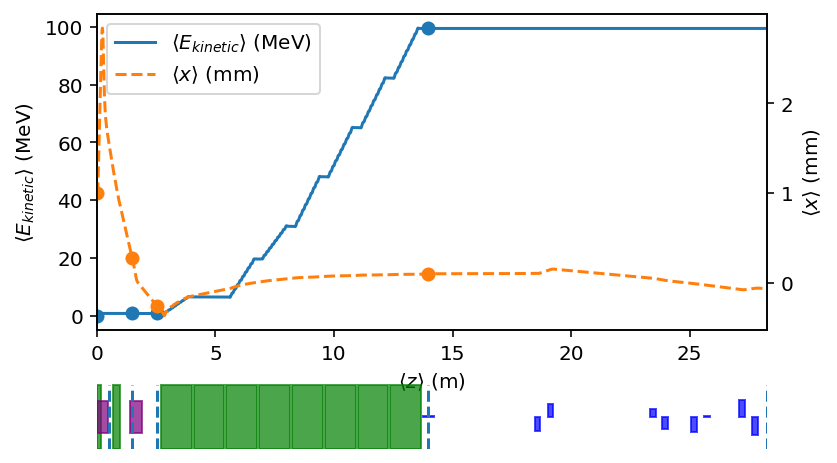

In [21]:
P0 = single_particle(pz=1e-9, x=1e-3)

I = Impact(initial_particles=P0)
stop_ele = I.lattice.pop(-1)
I.lattice.pop(1) # Remove the drift
I.input['lattice'] =  [timestep_ele] + I.lattice + deepcopy(LAT) + [stop_ele]

# Make a list of s
for elename in ['YAG01B_YAG1', 'CM01BEG', 'BEAM0']:
    
    s = tao.ele_head(elename)['s']
    name = elename.split('_')[0]
    ele = new_write_beam(name=name, s=s, ref_eles=I.lattice) # ref_eles will ensure that there are no naming conflicts
    I.add_ele(ele)

#I.lattice.insert(1, gun)
#I.lattice.insert(2, sol1)
I.input['fieldmaps'].update(FIELDMAPS)

I.ele_bookkeeper()

I.header['Dt'] = 5e-13

I.ele['stop_1']['s'] = ZSTOP
I.header['Bcurr'] = 0 # Turn off SC
I.verbose=False
I.run()
I.plot('mean_kinetic_energy', y2='mean_x')

In [22]:
!cat {I.path}/ImpactT.in

! Impact-T input file
!Npcol Nprow
1 1
!Dt Ntstep Nbunch
5e-13 1000000 1
!Dim Np Flagmap Flagerr Flagdiag Flagimg Zimage
6 1 1 0 2 0 0.02
!Nx Ny Nz Flagbc Xrad Yrad Perdlen
32 32 32 1 0.015 0.015 45.0
!Flagdist Rstartflg Flagsbstp Nemission Temission
16 0 0 0 0.0
!sigx(m) sigpx muxpx xscale pxscale xmu1(m) xmu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigy(m) sigpy muxpy yscale pyscale ymu1(m) ymu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigz(m) sigpz muxpz zscale pzscale zmu1(m) zmu2
0.0001 0.0 0.0 1.0 1.0 0.0 0
!Bcurr Bkenergy Bmass Bcharge Bfreq Tini
0.0 1.0 510998.95 -1.0 1000000000.0 0
!=================== LATTICE ===================
0 0 0 -4 0.0 0.0 0.5 1e-12 /!name:change_timestep_1
0 0 0 -5 0.0 0.0 -1000.0 /!name:2d_to_3d_spacecharge
0.175 0 0 105 0.0 20000000.0 185714285.714286 179.91966462707128 1 0.15 0.0 0.0 0.0 0.0 0.0 0 /!name:RFGUNB
0.48 0 0 105 0.00653 0 0 0 2 0.15 0.0 0.0 0.0 0.0 0.0 0.0559 /!name:SOL1B
0.3 0 0 105 0.659116 1800000.0 1300000000.0 216.7685022621053 3 0.15 0.0 0.0 0.0 0.0 

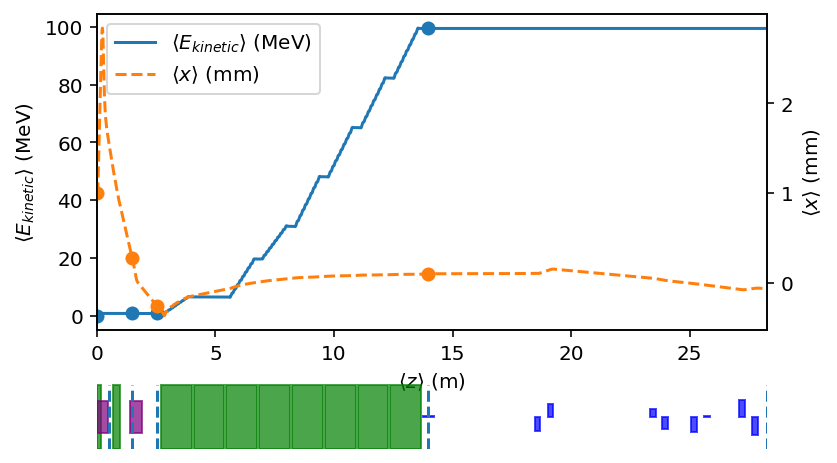

In [25]:
OUTPATH = os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1')
Iout = I.copy()
Iout.header['Flagerr'] = 1 # Allow offsets
Iout.header['Flagimg'] = 1
Iout.header['Zimage'] = 0.12 # Conservative image charge distance
Iout.header['Nemission'] = 900 # for cathode start
#Iout.total_charge = 100e-12 # Restore for SC calc
Iout.write_input(path=OUTPATH)
Iout.track1(x0=1e-3)
Iout.plot('mean_kinetic_energy', y2='mean_x')

In [26]:
!cat {OUTPATH}/ImpactT.in

! Impact-T input file
!Npcol Nprow
1 1
!Dt Ntstep Nbunch
5e-13 1000000 1
!Dim Np Flagmap Flagerr Flagdiag Flagimg Zimage
6 1 1 1 2 1 0.12
!Nx Ny Nz Flagbc Xrad Yrad Perdlen
32 32 32 1 0.015 0.015 45.0
!Flagdist Rstartflg Flagsbstp Nemission Temission
16 0 0 900 3.372134870829164e-26
!sigx(m) sigpx muxpx xscale pxscale xmu1(m) xmu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigy(m) sigpy muxpy yscale pyscale ymu1(m) ymu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigz(m) sigpz muxpz zscale pzscale zmu1(m) zmu2
0.0001 0.0 0.0 1.0 1.0 0.0 0
!Bcurr Bkenergy Bmass Bcharge Bfreq Tini
0.0 1.0 510998.95 -1.0 1000000000.0 -1.686067435414582e-26
!=================== LATTICE ===================
0 0 0 -4 0.0 0.0 0.5 1e-12 /!name:change_timestep_1
0 0 0 -5 0.0 0.0 -1000.0 /!name:2d_to_3d_spacecharge
0.175 0 0 105 0.0 20000000.0 185714285.714286 179.91966462707128 1 0.15 0.0 0.0 0.0 0.0 0.0 0 /!name:RFGUNB
0.48 0 0 105 0.00653 0 0 0 2 0.15 0.0 0.0 0.0 0.0 0.0 0.0559 /!name:SOL1B
0.3 0 0 105 0.659116 1800000.0 1300000000.0 

# Phase scan

In [ ]:
plist = np.linspace(280, 350, 16)
xlist = []
ylist = []

Itest = I.copy()
for p in plist:
    Itest.ele['BUN1B']['theta0_deg'] = p
    Itest.track1(x0=0)
    if 'particles' in Itest.output:
        Pf = Itest.particles['final_particles']
        x = Pf['mean_kinetic_energy']
        y = Pf['mean_z']
    else:
        x=0
        y=0
    xlist.append(x)
    ylist.append(y)
    
xlist = np.array(xlist)
ylist = np.array(ylist)
plt.plot(plist, xlist/1e6)
plt.title(f'{plist[xlist.argmax()]}')

# Check tracking

In [27]:
from pytao import Tao
from pytao.misc.markers import make_markers
from pmd_beamphysics import ParticleGroup
import pandas as pd
import numpy as np
import os


P0FILE = 'test.h5'
P0.write(P0FILE)

In [28]:
LATFILE = 'lat.bmad'
MARKERFILE = 'markers.bmad'

slist = np.linspace(0, ZSTOP, 150)
make_markers(slist, filename=MARKERFILE);

LAT = f"""
call, file = $LCLS_LATTICE/bmad/models/sc_inj/sc_inj.lat.bmad
call, file = {MARKERFILE}
"""

with open(LATFILE, 'w') as f:
    f.write(LAT)

In [29]:
%%time
tao = Tao(INIT + f' -lat {LATFILE}')
tao.cmd(f'set beam_init position_file = {P0FILE}')
tao.cmd('beamon')

CPU times: user 46.5 s, sys: 649 ms, total: 47.1 s
Wall time: 47.1 s


[]

In [30]:
ix = tao.lat_list('marker::*', 'ele.ix_ele')
df = pd.DataFrame(map(tao.bunch_params, ix))

PG1 = [ ParticleGroup(data=tao.bunch_data(i)) for i in ix]
len(PG1)

170

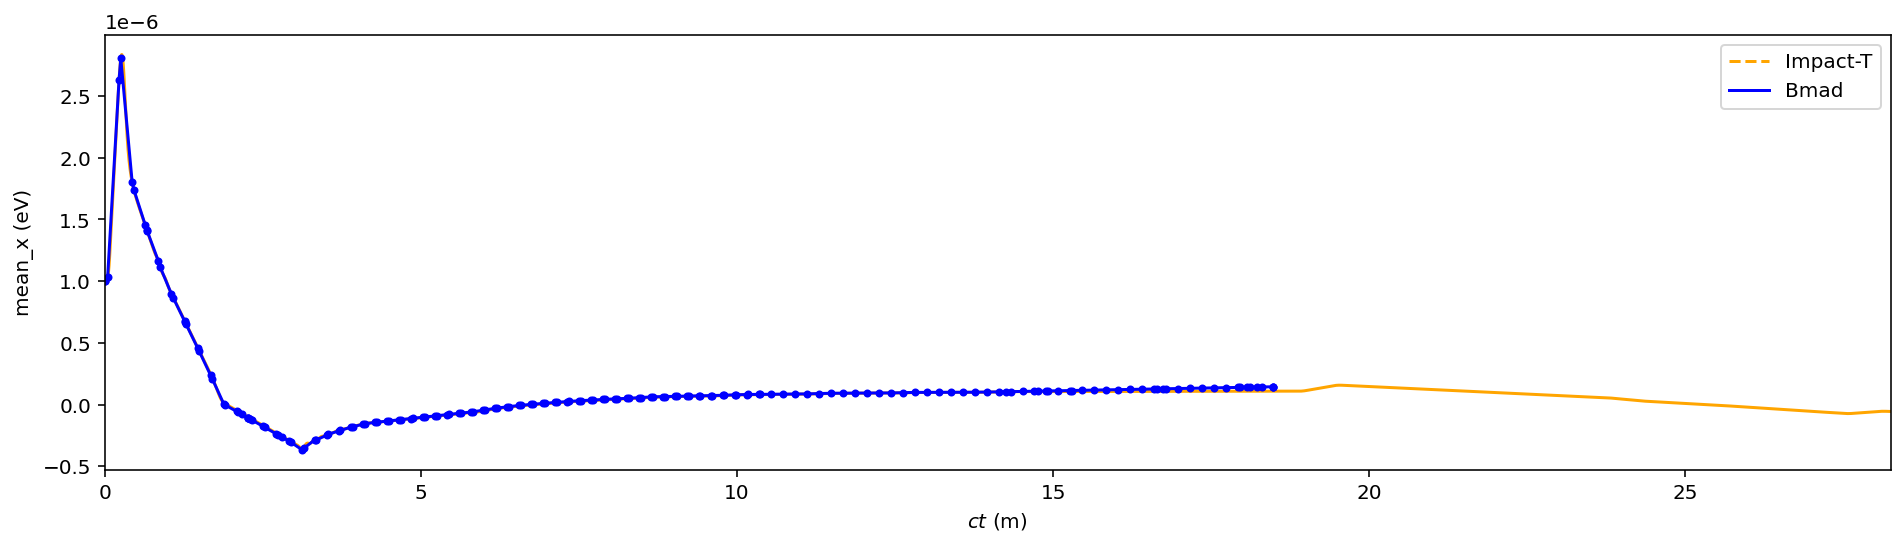

In [31]:
# Traces can be made by gathering the coordinate arrays

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16,4))

ykey = 'mean_x'
yscale = 1e-3
#yunit = r'µm'
yunit = 'eV'
ylabel = f'{ykey} ({yunit})'

# ax.plot(
#     [P.t*299792458 for P in  A.particles],
#     [P[ykey]*yscale for P in  A.particles], color='red', linestyle='--', marker='.',
# )

ax.plot(
     I.stat('t')*299792458,
    I.stat(ykey)*yscale,
    color='orange'
)
    

ax.plot(
    [P.t*299792458 for P in  PG1],
    [P[ykey]*yscale  for P in  PG1], color='blue', label='Bmad', marker='.',
)

ax.set_xlim(0, ZSTOP)
#ax.set_ylim(0.5e6, 2e6)

custom_lines = [Line2D([0], [0], color='orange', linestyle='--'),
                Line2D([0], [0], color='blue')]
ax.legend(custom_lines, ['Impact-T', 'Bmad'])

ax.set_xlabel(f'$ct$ (m)')
ax.set_ylabel(ylabel)
#ax.set_ylim(0, 1200)
#plt.title('Astra (red), Bmad (Blue) with fine Astra fieldmap')
plt.savefig('sc_inj-Bmad-Impact-comparison.png', bbox_inches='tight', dpi=150)

# Check phasing

In [ ]:
def Ez(ele, z=0, t_or_z=0):
    return list(map(float, tao.em_field(ele, 0, 0, z, t_or_z)[0].split(';') ))[-1]

In [ ]:
#tao.cmd('python em_field BUN1B|model 0 0 0 0')

In [ ]:
tlist = np.linspace(0, 1/(1.3e9), 100)
fields = [Ez('BUN1B', 0, t) for t in tlist]
plt.plot(fields)

In [ ]:
# ele = 'BUN1B'
# 
# freq = 1.3e9
# tlist = np.linspace(0, 1/freq, 1000)
# fields = np.array([Ez(ele, 0, t) for t in tlist])
# fields /= fields.max()
# 
# #phi0 from Tao
# phi0_tao = 4.4003401E-02
# 
# # Get ref_time_start
# ref_time_start = tao.ele_param(ele, 'ele.ref_time_start')['ele_ref_time_start']
# phi0_ref = freq*ref_time_start
# 
# phi0_tot = (-phi0_ref + phi0_tao) %1
# 
# ft  = freq*tlist
# 
# presumed = np.cos(2*np.pi*(ft  + (phi0_tot)))
# plt.plot(360*ft, presumed, label='presumed Bmad', marker='.')
# 
# plt.plot(360*ft, fields, label='em_field_calc')
# plt.legend()
# plt.xlabel('global phase (deg)')
# plt.ylabel(f'scaled field from {ele}')